# Inferring behavioral strategies during decision making using GLM-HMMs

In this notebook, we will show how to use choice data to derive hidden behavioral states using the NeMoS GLM-HMM implementation. We will use Nemos' Bernoulli GLM-HMM to model mice choices and extract their hidden behavioral states during a decision making task. As a result, we will replicate the previously published results from Ashwood et al. (2023). LINK REF

We have two main goals for this notebook:

1. How to use GLM-HMM to analyze real data / real world application

1.1 Data download
1.2 Data preprocessing

2. Demonstrate how to replicate published results using NeMoS

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs. If you need a refresher, please refer to our tutorial on GLMs and GLM-HMMs. Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to our tutorial for fine-grain details of the fitting algorithm and different initialization methods you could use to ensure the best possible fit and thus description of your data under this model.

add section of extra resources
- ssm tutorial

- write equations and we decide after, also graphical model

## Setup

In [2]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo
import pynapple as nap

from notebook_utils import *

seed = 0  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## Download and preprocessing of data
Normally, when importing an IBL dataset, you should follow this process:
XX
However, since we are interested in reproducing a particular set of figures, we will retrieve the already preprocessed data of a single mouse. If you are interested in understanding how this preprocessing took place, please refer to [ashwood's repo]

In [3]:
design_matrix, y_raw, session = load_data("IBL/CSHL_008_processed.npz")

'''
io = nmo.fetch.download_dandi_data(
    "000045/sub-00778394-c956-408d-8a6c-ca3b05a611d5",
    "sub-00778394-c956-408d-8a6c-ca3b05a611d5_ses-00594aec-bb70-4601-862d-63a31ef0e1c0_behavior+image.nwb"
)
'''

'\nio = nmo.fetch.download_dandi_data(\n    "000045/sub-00778394-c956-408d-8a6c-ca3b05a611d5",\n    "sub-00778394-c956-408d-8a6c-ca3b05a611d5_ses-00594aec-bb70-4601-862d-63a31ef0e1c0_behavior+image.nwb"\n)\n'

## 01. Understanding the task structure: IBL decision-making task

<center><img src="images/IBL_edited.png" alt="Task schematic" width="500" /></center>

<div style="text-align: center;">

  Task illustration. Modified from IBL et al. (2021) 
   <span id="cite1a"></span><a href="#ref1">[1a]</a>.
</div>

We will analyze the IBL decision-making task, which is a variation of the two-alternative forced-choice perceptual detection task (IBL et al., 2021 <span id="cite1b"></span><a href="#ref1">[1b]</a>). During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al. (2021) <span id="cite2a"></span><a href="#ref2">[2]</a>. If the mice chose the side correctly, they would receive a water reward; if not, a noise burst and there would be a 1 second timeout. 

For the first 90 trials of each session, the stimulus appeared randomly on either side of the screen; after that, the stimulus would appear on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. Same as in Ashwood et al., (2023)  <span id="cite1c"></span><a href="#ref1">[1c]</a>., we will only analyze the first 90 trials of each session (the ones with random appearance at either side).

First, let's see what the design matrix looks like. 

In [4]:
print(f"shape = {design_matrix.shape}")


shape = (5040, 3)


The design matrix has shape (n_timepoints, n_predictors). 
- PREDICTOR 1 - stimuli: grating contrast and position: the absolute value indicates the intensity of the contrast, whilst the sign indicates whether it was shown at the left (-) or the right (+) of the animal.
- PREDICTOR 2 - previous choice: choice made by the animal in the immediate previous timepoint - simply repeat the choice. The choice is coded by the sign: left (-) or right (+)
- PREDICTOR 3 - win-stay lose-shift: if the previous choice was rewarded, then repeat the choice; conversely, shift. Also coded with the sign: left (-) or right (+)

If the animal was engaged with the task, the only predictor that should be relevant is PREDICTOR 1 - stimuli

This will be followed by the preprocessing and at the end of the section we'd have a design matrix built w nemos & pynapple

In [5]:
print(f"input = {design_matrix}")    

input = [[-2.09318779e+00 -1.00000000e+00 -1.00000000e+00]
 [ 2.09541483e+00 -1.00000000e+00 -1.00000000e+00]
 [ 5.24688844e-01  1.00000000e+00  1.00000000e+00]
 ...
 [ 2.09541483e+00  1.00000000e+00 -1.00000000e+00]
 [ 1.11351692e-03  1.00000000e+00  1.00000000e+00]
 [ 1.32007349e-01  1.00000000e+00 -1.00000000e+00]]


In [6]:
# plot of task variables
X_mouse = design_matrix 

The choices are coded with 0 (choice left) and 1 (choice right)

In [7]:
# Choices
choices_mouse = y_raw.flatten() # Convert to (n_timepoints,) | maybe I should pass the data
print(set(choices_mouse))

{np.int64(0), np.int64(1)}


Importantly, do not do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials, and we use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute two different sessions as if they were one. 

With NeMoS, we have two ways of indicating the beginning of a new session. When using a design matrix and a choice vector that are Numpy objects, NeMoS treats NaNs either in the input matrix X or in the choice vector y as new sessions. You can also use Pynapple objects to demarcate sessions, which is what we will use now.

!! careful, if your choice data contains nan values, they will be handled as new sessions, so make sure to address this promptly

In [8]:
# I would need to explain what the session array is above if I want to do this this way. I still am not super sure whether I want to do the data preprocessing here or not.

# new_sess array
# Create array of 1s and 0s marking session boundaries
new_sess_mouse = np.zeros(len(session), dtype=int)
new_sess_mouse[0] = 1  # First entry is always 1

# Mark where session changes
new_sess_mouse[1:] = (session[1:] != session[:-1]).astype(int)
new_sess_mouse

array([1, 0, 0, ..., 0, 0, 0], shape=(5040,))

Conversion to pynapple objects

admonition to send people to pynapple!

In [9]:
new_sess_pos = np.array(np.where(new_sess_mouse==1))
sess_length = np.array(np.where(new_sess_mouse==1))[0][1] - 1 # substracting the starting trial

choices_tsd = nap.Tsd(t = np.arange(choices_mouse.shape[0]), d=choices_mouse, time_support=nap.IntervalSet(start=new_sess_pos, end = new_sess_pos+ sess_length))

## Fitting a GLM-HMM with NeMoS (Maximum Likelihood)
The model:
- We are using a Bernoulli GLM

_math for it should be here, not explanation, just equations and an admonition to point them to more detailed notebooks_


First you need to initialize the object. The only obligatory thing you have to declare is the number of states which, in our case is 3. The default observation model for the GLM-HMM is this model is Bernoulli, but we also have Poisson, Gamma, Negative Binomial and Gaussian available. Moreover, if desired, you can also set a different observation model of your choice. You can also personalize the inverse link function.

! admonition on convexity non guaranteed for all likelihood functions, refer to Escola paper and also to the other notebook.

In [10]:
n_states = 3
model = nmo.glm_hmm.GLMHMM(n_states)
print(model)

GLMHMM(
    n_states=3,
    observation_model=BernoulliObservations(),
    inverse_link_function=logistic,
    regularizer=UnRegularized(),
    solver_name='GradientDescent',
    initialization_funcs={'glm_params_init': <function random_glm_params_init at 0x161884d60>, 'scale_init': <function ones_scale_init at 0x161e93420>, 'transition_proba_init': <function sticky_transition_proba_init at 0x161e93240>, 'initial_proba_init': <function uniform_initial_proba_init at 0x161e93920>},
    maxiter=1000,
    tol=1e-08
)


explain all the things it has inside

and then fit it. The fit function takes two mandatory arguments: the design matrix which we discussed above and the vector (or pynapple object) of neural activity or behavioral data(our case) you want to extract hidden states from. 

By default, the initialization algorithm for EM is the following[:]. However, you can also set the initial parameters of your choice.

! admonition on how to choose a good initialization of parameters
Probably point them to the other notebook

In [11]:
model.fit(X_mouse, choices_mouse)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x161327b00>
,regularizer,UnRegularized()
,regularizer_strength,None
,dirichlet_prior_alphas_init_prob,None
,dirichlet_prior_alphas_transition,None
,solver_name,'GradientDescent'
,solver_kwargs,{}
,initialization_funcs,"{'glm_params_init': <function ran...t 0x161884d60>, 'initial_proba_init': <function uni...t 0x161e93920>, 'scale_init': <function one...t 0x161e93420>, 'transition_proba_init': <function sti...t 0x161e93240>}"
,maxiter,1000


We can retrieve different metrics after fitting, and we can see the full list using .get_params()

In [12]:
model.get_params # stuff you can set when crossval

# parameters
# model.coef_
# mode.intercept_
# model.initial_prob_




<bound method Base.get_params of GLMHMM(
    n_states=3,
    observation_model=BernoulliObservations(),
    inverse_link_function=logistic,
    regularizer=UnRegularized(),
    solver_name='GradientDescent',
    initialization_funcs={'glm_params_init': <function random_glm_params_init at 0x161884d60>, 'scale_init': <function ones_scale_init at 0x161e93420>, 'transition_proba_init': <function sticky_transition_proba_init at 0x161e93240>, 'initial_proba_init': <function uniform_initial_proba_init at 0x161e93920>},
    maxiter=1000,
    tol=1e-08
)>

If we want to see our glm-hmm parameters, we can call

In [13]:
model.coef_

Array([[ 0.95086584,  6.75830724,  5.30450459],
       [ 1.76205744,  0.31747617, -0.1951703 ],
       [ 0.00795015, -0.08518533,  0.30085115]], dtype=float64)

### Retrieved parameters

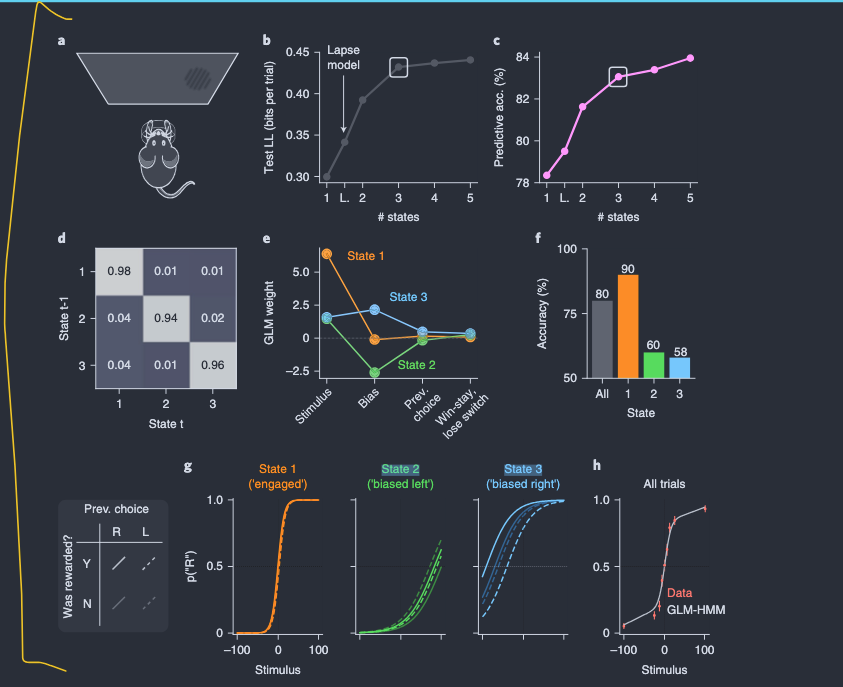

follow state descriptions in the paper
if you dont segment the paper then you would not be able to see some effects (see in what way they do that) -> explain at the very begining as a motivation and in the end as an interpretation -> why they thought to use this method

### Plot 2e
50%

In [14]:
# True vars - to be used for plot generation 
# Initial guess - Initial prob
initial_prob_initial_guess_mouse = jnp.array([0.95, 0.025, 0.025])

true_intercept = np.array(
    [1, -3, 3],dtype=float  # Bias - Intercept
)
# Transition matrix
true_transition_prob = np.array(
    [[0.98, 0.01, 0.01], [0.04, 0.94, 0.02], [0.04, 0.01, 0.96]]
)

# True mouse projection weights
X_labels_mouse = ["bias", "stimulus", "Prev.choice", "WSLS"]

projection_weights_true_values_mouse = np.array(
    [
        [6, 2, 2],      # Stimulus,
        [-.1, .1, .2],  # Previous choice
        [-.1, .1, .2]  # Win-stay, lose-switch
        
    ]
    , dtype=float  
)
projection_weights_initial_guess_mouse = projection_weights_true_values_mouse

# True mouse intercept
true_intercept_mouse = true_intercept 
intercept_initial_guess_mouse = true_intercept_mouse

true_transition_prob_mouse = true_transition_prob
transition_prob_initial_guess_mouse = true_transition_prob_mouse
# High proba in diagonal - low elsewhere
#transition_prob_initial_guess_mouse = np.ones(true_transition_prob.shape) * 0.05
#transition_prob_initial_guess_mouse[np.diag_indices(true_transition_prob.shape[1])] = 0.9



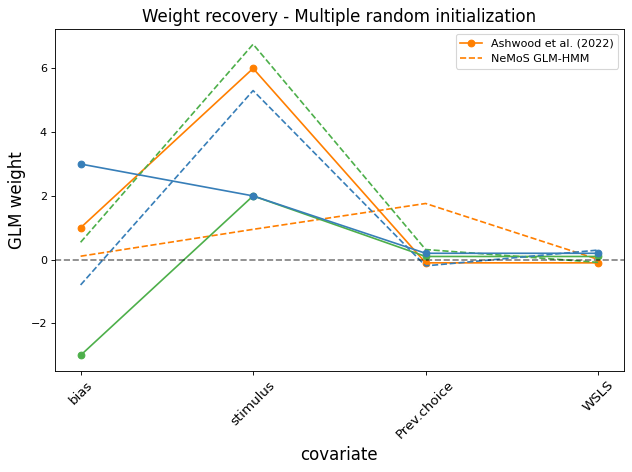

In [15]:
# Stack array for plotting
stacked_arr = np.vstack([true_intercept_mouse, projection_weights_true_values_mouse])
stacked_arr

plot_glm_weights(
    model.coef_.shape[0]+ 1,
    3, # n states
    stacked_arr,
    model.intercept_,
    model.coef_,
    X_labels_mouse,
    "Multiple random initialization",
    )


### Plot 2d
Pending

NameError: name 'log_transition_matrix' is not defined

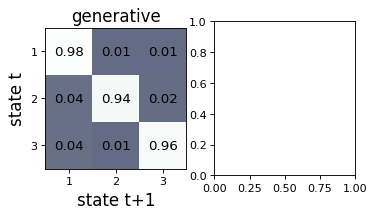

In [16]:
fig = plt.figure(figsize=(5, 2.5), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
gen_trans_mat = true_transition_prob_mouse
plt.imshow(gen_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(gen_trans_mat.shape[0]):
    for j in range(gen_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(gen_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.ylim(n_states - 0.5, -0.5)
plt.ylabel("state t", fontsize = 15)
plt.xlabel("state t+1", fontsize = 15)
plt.title("generative", fontsize = 15)


plt.subplot(1, 2, 2)
recovered_trans_mat = np.exp(log_transition_matrix)
plt.imshow(recovered_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(recovered_trans_mat.shape[0]):
    for j in range(recovered_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(recovered_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.ylim(n_states - 0.5, -0.5)
plt.title("recovered", fontsize = 15)
plt.subplots_adjust(0, 0, 1, 1)

### Plot 2f

In [ ]:
# Should put here the corresponding psychometric curves

### Posterior state probabilities
We can also show the posterior state probabilities

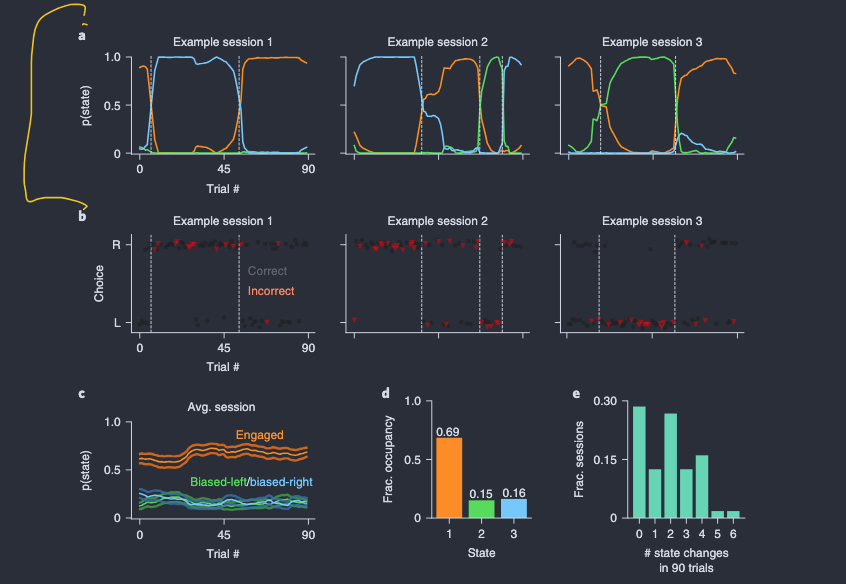

In [ ]:
plt.model.smooth_proba(X_mouse, choices_mouse)

Array([[1.32363851e-65, 1.00000000e+00, 2.24359439e-54],
       [5.84835407e-04, 9.97027667e-01, 2.38749723e-03],
       [1.67087787e-03, 9.93840986e-01, 4.48813596e-03],
       ...,
       [9.64005213e-01, 1.49785373e-02, 2.10162500e-02],
       [9.54396859e-01, 1.98217820e-02, 2.57813588e-02],
       [9.30668647e-01, 2.52937399e-02, 4.40376130e-02]],      dtype=float64, weak_type=True)

## Fitting a GLM-HMM with NeMoS (MAP)


## 02. Understanding fitting: Hierarchical fitting process
Explanation of Ashwood fitting process.

I think it would be nice to showcase a small version of the hierarchical fitting process here, only because people using the tool might be interested in running similar analyses

## 03. Fitting the data
- Plot state probability against choices to show that in the state in which the animal considers the stimuli it performs better

## 04. Comparing results
1. Show weights, initial and transition proba recoveries
2. Show log likelihood
2. Benchmark with ssm

## Conclusion

## Other resources

## References

<a id="ref1"></a><a href="#cite1a">[1a]</a> <a href="#cite1b">[1b]</a> <a href="#cite1c">[1c]</a> <a href="#cite1d">[1d]</a> Pillow, J. W., Shlens, J., Paninski, L., Sher, A., Litke, A. M., Chichilnisky, E. J., & Simoncelli, E. P. (2008). Spatio-temporal correlations and visual signalling in a complete neuronal population. Nature, 454(7207), 995-999. https://doi.org/10.1038/nature07140

## Other scripts (to be removed)

### Reproducing error of using a Pynapple object for choice data and using array with NaN to segment sessions
when both are different lengths it breaks even though it shouldnt.
error: my choices are not a valid jax type

In [27]:
from insert_nans import *

In [28]:
# Error reproduction
# Stimuli shown to the "mice"
stim_vals = [-1, -0.5, -0.25, -0.125,
    -0.0625, 0, 0.0625, 0.125, 0.25, 0.5, 1,
]

# Generate random sequence of stimuli for simulation - this design matrix is stupid because its the stimuli repeated three times
X = np.random.choice(stim_vals, (5040,3))

# Session starts
new_sess_rand_pos =  np.array([0,   90,  180,  270,  360,  450,  540,  630,  720,  810,  900,
         990, 1080, 1170, 1260, 1350, 1440, 1530, 1620, 1710, 1800, 1890,
        1980, 2070, 2160, 2250, 2340, 2430, 2520, 2610, 2700, 2790, 2880,
        2970, 3060, 3150, 3240, 3330, 3420, 3510, 3600, 3690, 3780, 3870,
        3960, 4050, 4140, 4230, 4320, 4410, 4500, 4590, 4680, 4770, 4860,
        4950])
# Session lengths
sess_rand_length = new_sess_rand_pos[1] - 1 # substracting the starting trial

# Set up rand choices
choices_mouse_rand = np.random.choice([0,1], 5040)

# Set up Tsd with choices with timesupport corresponding to epochs
choices_rand_tsd = nap.Tsd(t = np.arange(choices_mouse_rand.shape[0]), d=choices_mouse_rand, time_support=nap.IntervalSet(start=new_sess_rand_pos, end = new_sess_rand_pos + sess_rand_length))

choices_mouse_rand

result = insert_nan_every_n(choices_mouse_rand, 90)
result_x = insert_nan_rows_every_n(X, 90)

# Initialize and fit
model = nmo.glm_hmm.GLMHMM(3)
#model.fit(X, choices_rand_tsd)
model.fit(result_x, result)

ValueError: GLM-HMM requires continuous time-series data. NaN values must only appear at the beginning or end of the data, not in the middle. Found NaN values within the time series, which would break the forward-backward algorithm. Please ensure your data is continuous or split it into separate epochs at the gaps.